In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import  cv2 as cv
import os


In [2]:
train = ImageDataGenerator(
    rescale= 1/255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)
test = ImageDataGenerator(rescale= 1/255)


In [3]:
'a:/project/menWomenClassification-master/menWomenClassification-master/data'

'a:/project/menWomenClassification-master/menWomenClassification-master/data'

In [4]:
train_dataset = train.flow_from_directory('a:/project/menWomenClassification-master/menWomenClassification-master/data/train',
                                          target_size=(224, 224),
                                          batch_size = 16,
                                          class_mode='binary')
test_dataset = test.flow_from_directory('a:/project/menWomenClassification-master/menWomenClassification-master/data/test',
                                          target_size=(224, 224),
                                          batch_size = 16,
                                          class_mode='binary')
valid_dataset = test.flow_from_directory('a:/project/menWomenClassification-master/menWomenClassification-master/data/valid',
                                          target_size=(224, 224),
                                          batch_size = 16,
                                          class_mode='binary')

Found 1590 images belonging to 2 classes.


Found 434 images belonging to 2 classes.


Found 797 images belonging to 2 classes.


In [5]:
train_dataset.class_indices

{'men': 0, 'women': 1}

In [6]:
train_dataset.classes

array([0, 0, 0, ..., 1, 1, 1], shape=(1590,), dtype=int32)

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze pre-trained weights

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # Regularization to prevent overfitting
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)


In [8]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)


In [9]:
# Phase 1: Train the classification head only (4 epochs)
print('Starting Phase 1 (classification head warm-up)...')
model.fit(
    train_dataset,
    epochs=4,
    validation_data=test_dataset
)

# Phase 2: Unfreeze the top 60 layers of MobileNetV2 base and fine-tune (8 epochs)
print('Starting Phase 2 (fine-tuning)...')
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 60
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a very low learning rate (1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback to decay learning rate on plateau
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

# Train for another 8 epochs
model.fit(
    train_dataset,
    epochs=8,
    validation_data=test_dataset,
    callbacks=[lr_callback]
)


Starting Phase 1 (classification head warm-up)...


C:\Users\umang\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/4


  1/100 ━━━━━━━━━━━━━━━━━━━━ 7:09 4s/step - accuracy: 0.5000 - loss: 1.0180

  2/100 ━━━━━━━━━━━━━━━━━━━━ 39s 403ms/step - accuracy: 0.4688 - loss: 1.1186

...

 97/100 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8639 - loss: 0.2837

 98/100 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.8640 - loss: 0.2837

 99/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.8641 - loss: 0.2837

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8642 - loss: 0.2837

100/100 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.8730 - loss: 0.2812 - val_accuracy: 0.9217 - val_loss: 0.2131 - learning_rate: 1.0000e-05


In [10]:
test_loss, test_accuracy = model.evaluate(train_dataset)

  1/100 ━━━━━━━━━━━━━━━━━━━━ 1:49 1s/step - accuracy: 0.8750 - loss: 0.2256

  2/100 ━━━━━━━━━━━━━━━━━━━━ 1:11 732ms/step - accuracy: 0.9062 - loss: 0.1923

  3/100 ━━━━━━━━━━━━━━━━━━━━ 1:07 694ms/step - accuracy: 0.9028 - loss: 0.1944

  4/100 ━━━━━━━━━━━━━━━━━━━━ 1:05 684ms/step - accuracy: 0.9076 - loss: 0.1868

  5/100 ━━━━━━━━━━━━━━━━━━━━ 1:06 698ms/step - accuracy: 0.9110 - loss: 0.1823

...

 97/100 ━━━━━━━━━━━━━━━━━━━━ 2s 888ms/step - accuracy: 0.9230 - loss: 0.1909

 98/100 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step - accuracy: 0.9230 - loss: 0.1910

 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.9230 - loss: 0.1911

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 875ms/step - accuracy: 0.9231 - loss: 0.1912

100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 878ms/step - accuracy: 0.9239 - loss: 0.1992


In [11]:
print(f"test loss: {test_loss}")
print(f"test accuracy: {test_accuracy}")

test loss: 0.19922079145908356
test accuracy: 0.9238993525505066


In [12]:
model.save('new_maleVSfemaleClassification.h5')
print('Model saved Successfullyll..')

Model saved Successfullyll..


In [13]:
dir_path ='a:/project/menWomenClassification-master/menWomenClassification-master/data/valid'
test_Images_paths =[]
for i in os.listdir(dir_path):
    img_path = f"{dir_path}/{i}"
    for j in os.listdir(img_path):
        img_path1 = f"{img_path}/{j}"
        test_Images_paths.append(img_path1)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


man


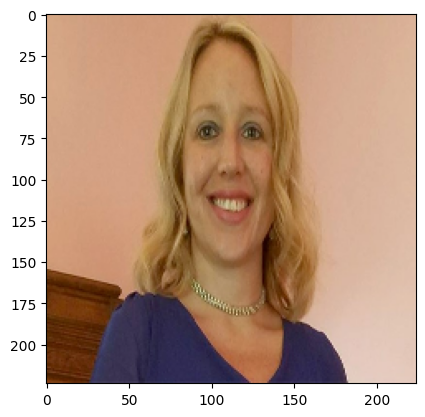

In [14]:
import random
ind = random.randint(0,len(test_Images_paths))
ran_Img_path = test_Images_paths[ind]
imagel = cv.imread(ran_Img_path)
img = cv.cvtColor(imagel, cv.COLOR_RGB2BGR)
img = cv.resize(img, (224,224) )
plt.imshow(img)
image = load_img(f'{ran_Img_path}', target_size=(224, 224))  # Adjust the size as per your model
image = img_to_array(image)
image = np.expand_dims(image, axis=0)

y = model.predict(image)

y_pred = y>0.5
if y_pred == 0:
    print("man")

else:
    print("woman")

Model saved Successfullyll..


In [15]:
# cam = cv.VideoCapture(0)
# while True:
#     rat, frame = cam.read()
#     cv.imshow("Camra", frame)
    
#     image = load_img(frame, target_size=(224, 224))  # Adjust the size as per your model
#     image = img_to_array(image)
#     image = image / 255.0
#     image = np.expand_dims(image, axis=0) # Add batch dimension (1, 224, 224, 3)

#     y = model.predict(image)
#     # print(y*100)
#     y_pred = y>0.5
#     if y_pred==0:
#         print(f"Model Perdict 'man' with {y[0][0]*100}%")
#     else:
#         print(f"Model Perdict 'woman' with {y[0][0]*100} %")

#     if cv.waitKey(1) & 0xFF == ord('q'):
#         break
# cam.release()
# cv.destroyAllWindows()